# IchiV3 WhaleCap — GMX Vault Performance Report

**Strategy:** IchiV3_LS_Static_WhaleCap — Dual long/short Ichimoku trend-following with OI & pool liquidity caps  
**Exchange:** GMX (perpetual futures, isolated margin)  
**Timeframe:** 1h execution  
**Direction:** Long & Short  
**Benchmark:** BTC (Bitcoin buy-and-hold via Yahoo Finance)  
**Note:** Trades force-closed at backtest boundary are excluded from all metrics.

In [1]:
# ============================================================
# CONFIGURATION — Edit these variables for your strategy/exchange
# ============================================================

CONFIG_FILE = 'experiments/ichiv2-gmx/020-v2wc-vs-v3wc-final/configs/arm_d_v3wc_best.json'
SECRETS_CONFIG = 'configs/ichiv2_gmx_backtest.secrets.json'
STRATEGY_NAME = 'IchiV3_LS_Static_WhaleCap'
TIMERANGE = '20210106-20260312'
TIMEFRAME = '1h'
DATA_DIR = 'user_data/data/gmx_complete_w_binance'
CAN_SHORT = True

# Report labels
REPORT_TITLE = 'IchiV3 WhaleCap \u2014 GMX Vault'
EQUITY_TITLE = 'IchiV3_LS_Static_WhaleCap \u2014 GMX'
METRICS_CAPTION = 'IchiV3 WhaleCap vs BTC Benchmark'

# HTML export (set to None to skip export)
HTML_OUTPUT_FILENAME = 'ichiv3_whalecap_gmx_vault_quantstats_report.html'

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, io, logging
logging.disable(logging.CRITICAL)
for h in logging.root.handlers[:]: logging.root.removeHandler(h)
_stdout, _stderr = sys.stdout, sys.stderr
sys.stdout, sys.stderr = io.StringIO(), io.StringIO()

import nest_asyncio
nest_asyncio.apply()

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timedelta
from copy import deepcopy

import quantstats as qs
qs.extend_pandas()

import eth_defi.gmx.freqtrade.patched_entrypoint  # enable GMX exchange in ccxt

from freqtrade.configuration import Configuration
from freqtrade.data.history import get_timerange
from freqtrade.persistence import Trade
from freqtrade.optimize.backtesting import Backtesting
from freqtrade.util import get_dry_run_wallet

sys.stdout, sys.stderr = _stdout, _stderr

REPO_ROOT = Path('/home/ubuntu/dev/gmx-ccxt-freqtrade')
os.chdir(REPO_ROOT)
None

In [3]:
_stdout, _stderr = sys.stdout, sys.stderr
sys.stdout, sys.stderr = io.StringIO(), io.StringIO()

config = Configuration.from_files([CONFIG_FILE, SECRETS_CONFIG])
config['strategy'] = STRATEGY_NAME
config['timeframe'] = TIMEFRAME
config['datadir'] = Path(DATA_DIR)
config['dry_run'] = True
config['timerange'] = TIMERANGE
config['can_short'] = CAN_SHORT
config['api_server'] = {
    'enabled': False, 'listen_ip_address': '127.0.0.1',
    'listen_port': 8080, 'username': '', 'password': '',
}
config['telegram'] = {'enabled': False, 'token': '', 'chat_id': ''}

backtesting = Backtesting(config)
backtesting._set_strategy(backtesting.strategylist[0])
strategy = backtesting.strategy
data, timerange = backtesting.load_bt_data()
processed = strategy.advise_all_indicators(data)
min_date, max_date = get_timerange(processed)

Trade.reset_trades()
result = backtesting.backtest(processed=deepcopy(processed), start_date=min_date, end_date=max_date)
trades = result['results']
Backtesting.cleanup()
Trade.reset_trades()

sys.stdout, sys.stderr = _stdout, _stderr

total_trades_before_filter = len(trades)
trades = trades[trades['exit_reason'] != 'force_exit'].copy()
total_trades_after_filter = len(trades)
n_force_exit = total_trades_before_filter - total_trades_after_filter

winning_trades = len(trades[trades['profit_abs'] > 0])
losing_trades = len(trades[trades['profit_abs'] <= 0])
win_rate_pct = (winning_trades / total_trades_after_filter * 100) if total_trades_after_filter > 0 else 0.0

starting_balance = get_dry_run_wallet(config)
trades_sorted = trades.sort_values('close_date').copy()
trades_sorted['equity'] = starting_balance + trades_sorted['profit_abs'].cumsum()
trades_sorted = trades_sorted.set_index('close_date')
daily_equity = trades_sorted['equity'].resample('D').last().ffill()
date_range = pd.date_range(start=daily_equity.index.min(), end=daily_equity.index.max(), freq='D')
daily_equity = daily_equity.reindex(date_range).ffill()
if daily_equity.iloc[0] != starting_balance:
    first_date = daily_equity.index[0] - pd.Timedelta(days=1)
    daily_equity = pd.concat([pd.Series([starting_balance], index=[first_date]), daily_equity])
returns = daily_equity.pct_change().dropna()
returns.index = returns.index.tz_localize(None)

benchmark = qs.utils.download_returns('BTC-USD', period='max')
benchmark = benchmark.loc[returns.index.min():returns.index.max()]
benchmark.index = benchmark.index.tz_localize(None)
benchmark.name = 'BTC'

In [4]:
if n_force_exit > 0:
    _color, _bg = '#856404', '#fff3cd'
    _icon = '\u26a0\ufe0f'
    _msg = f'{_icon} <b>{n_force_exit} force_exit trade(s) removed</b> from {total_trades_before_filter} total trades (backtest boundary artifacts).'
else:
    _color, _bg = '#155724', '#d4edda'
    _icon = '\u2705'
    _msg = f'{_icon} <b>No force_exit trades found.</b> All {total_trades_after_filter} trades used in metrics.'
from IPython.display import display, HTML
display(HTML(f'<div style="padding:12px 16px;background:{_bg};color:{_color};border-radius:6px;font-size:14px;margin:4px 0">{_msg}</div>'))

---
## Performance Summary

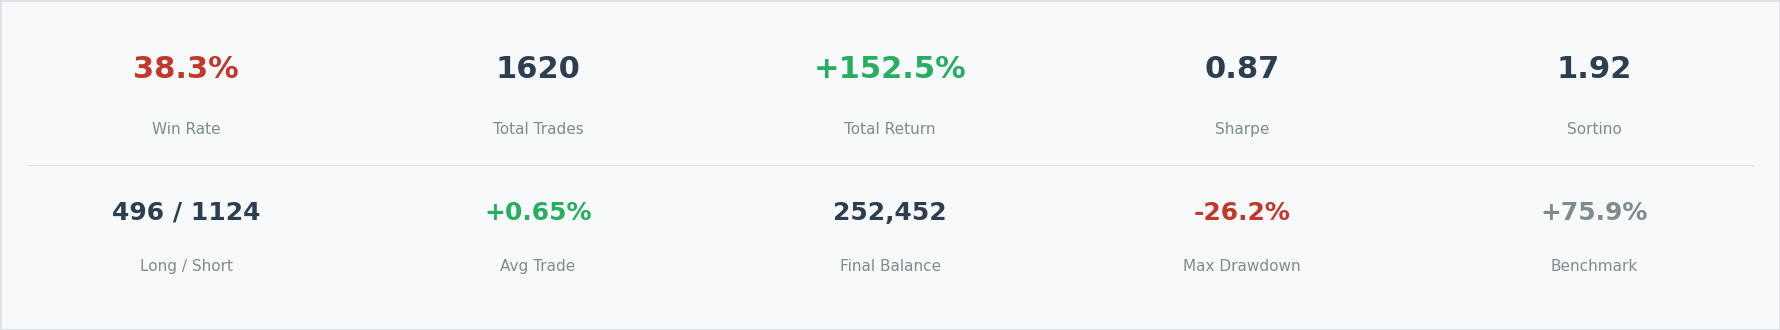

In [5]:
fig, ax = plt.subplots(figsize=(18, 3.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2.6)
ax.axis('off')

equity = starting_balance * (1 + returns).cumprod()
final_val = equity.iloc[-1]
total_ret = (final_val / starting_balance - 1) * 100
sharpe = qs.stats.sharpe(returns)
sortino = qs.stats.sortino(returns)
max_dd = qs.stats.max_drawdown(returns) * 100
avg_trade = trades['profit_ratio'].mean() * 100 if len(trades) > 0 else 0
bench_ret = (1 + benchmark).cumprod().iloc[-1] - 1 if len(benchmark) > 0 else 0

long_trades = trades[trades['is_short'] == False]
short_trades = trades[trades['is_short'] == True]

row1 = [
    ('Win Rate', f'{win_rate_pct:.1f}%', '#27ae60' if win_rate_pct >= 50 else '#c0392b'),
    ('Total Trades', f'{total_trades_after_filter}', '#2c3e50'),
    ('Total Return', f'{total_ret:+.1f}%', '#27ae60' if total_ret >= 0 else '#c0392b'),
    ('Sharpe', f'{sharpe:.2f}', '#2c3e50'),
    ('Sortino', f'{sortino:.2f}', '#2c3e50'),
]
row2 = [
    ('Long / Short', f'{len(long_trades)} / {len(short_trades)}', '#2c3e50'),
    ('Avg Trade', f'{avg_trade:+.2f}%', '#27ae60' if avg_trade >= 0 else '#c0392b'),
    ('Final Balance', f'{final_val:,.0f}', '#2c3e50'),
    ('Max Drawdown', f'{max_dd:.1f}%', '#c0392b'),
    ('Benchmark', f'{bench_ret*100:+.1f}%', '#7f8c8d'),
]

for i, (label, value, color) in enumerate(row1):
    x = i * 2 + 1
    ax.text(x, 2.1, value, ha='center', va='center', fontsize=22, fontweight='bold', color=color)
    ax.text(x, 1.6, label, ha='center', va='center', fontsize=11, color='#7f8c8d')

ax.plot([0.1, 9.9], [1.3, 1.3], color='#dee2e6', linewidth=0.8)

for i, (label, value, color) in enumerate(row2):
    x = i * 2 + 1
    ax.text(x, 0.9, value, ha='center', va='center', fontsize=18, fontweight='bold', color=color)
    ax.text(x, 0.45, label, ha='center', va='center', fontsize=11, color='#7f8c8d')

fig.patch.set_facecolor('#f8f9fa')
fig.patch.set_edgecolor('#dee2e6')
fig.patch.set_linewidth(1)
plt.tight_layout()
plt.show()

---
## Equity Curve

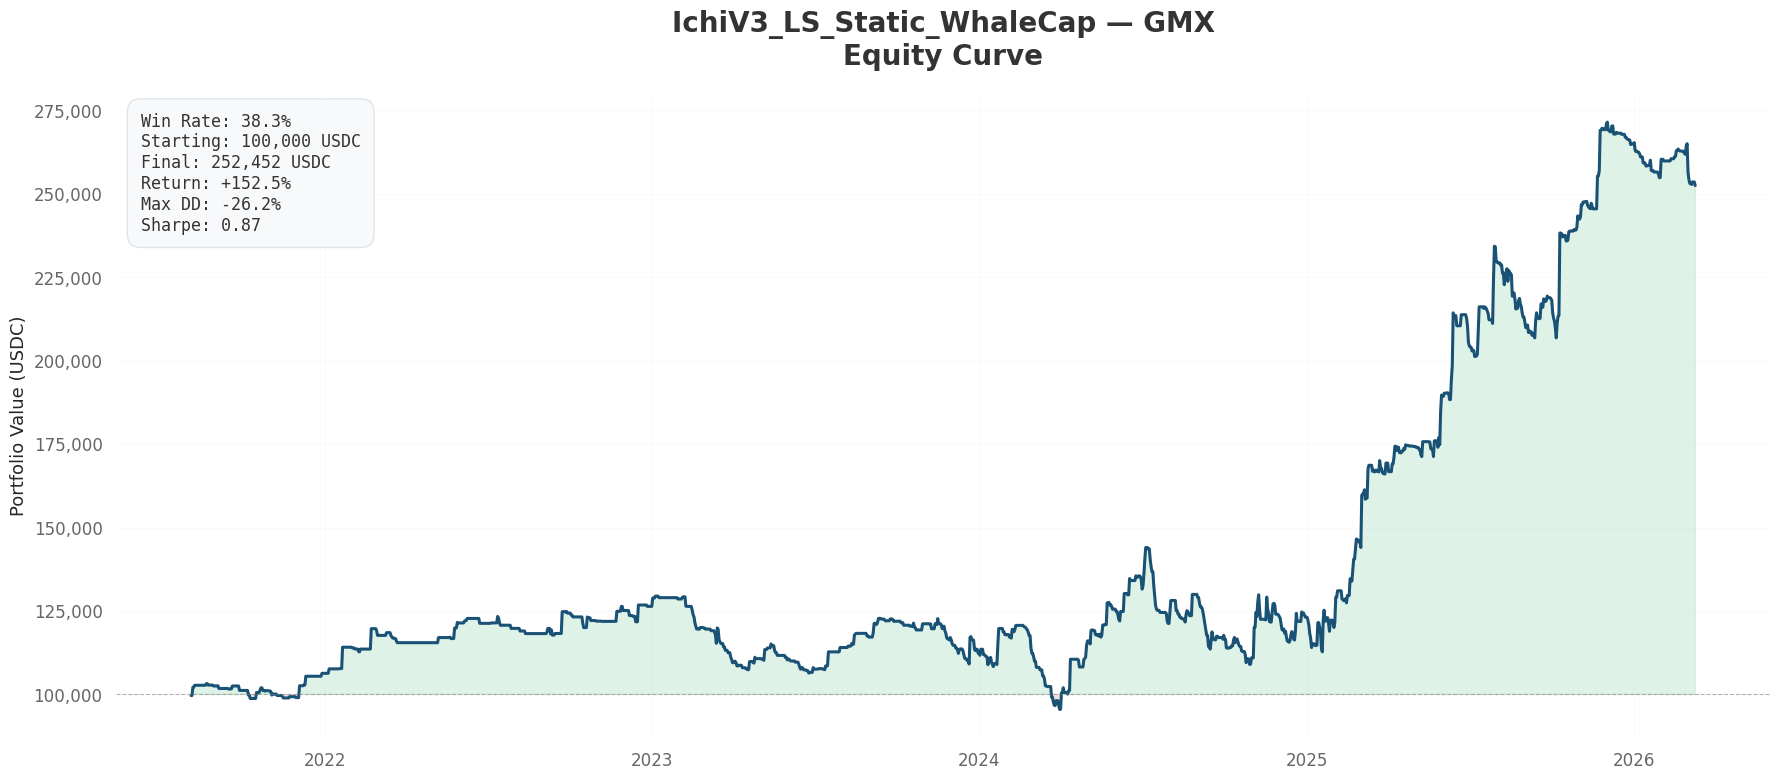

In [6]:
fig, ax = plt.subplots(figsize=(18, 8))

equity = starting_balance * (1 + returns).cumprod()

ax.plot(equity.index, equity.values, linewidth=2.2, color='#1a5276')
ax.fill_between(equity.index, starting_balance, equity.values,
                where=(equity.values >= starting_balance), alpha=0.15, color='#27ae60', interpolate=True)
ax.fill_between(equity.index, starting_balance, equity.values,
                where=(equity.values < starting_balance), alpha=0.15, color='#c0392b', interpolate=True)
ax.axhline(y=starting_balance, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_title(f'{EQUITY_TITLE}\nEquity Curve', fontsize=20, fontweight='bold', pad=20)
ax.set_ylabel(f"Portfolio Value ({config['stake_currency']})", fontsize=13)
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

textstr = (f"Win Rate: {win_rate_pct:.1f}%\n"
           f"Starting: {starting_balance:,.0f} {config['stake_currency']}\n"
           f"Final: {final_val:,.0f} {config['stake_currency']}\n"
           f"Return: {total_ret:+.1f}%\n"
           f"Max DD: {max_dd:.1f}%\n"
           f"Sharpe: {sharpe:.2f}")
props = dict(boxstyle='round,pad=0.8', facecolor='#f8f9fa', edgecolor='#dee2e6', alpha=0.9)
ax.text(0.015, 0.97, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', fontfamily='monospace', bbox=props)

plt.tight_layout()
plt.show()

---
## QuantStats Tearsheet


Parameter       Value
--------------  -------
Benchmark       BTC
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           BTC         Strategy
-------------------------  ----------  ----------
Start Period               2021-08-05  2021-08-05
End Period                 2026-03-10  2026-03-10
Risk-Free Rate             0.0%        0.0%
Time in Market             100.0%      46.0%

Cumulative Return          75.93%      152.45%
CAGR﹪                     8.85%       14.91%

Sharpe                     0.41        0.87
Prob. Sharpe Ratio         85.69%      99.38%
Smart Sharpe               0.38        0.8
Sortino                    0.6         1.92
Smart Sortino              0.55        1.77
Sortino/√2                 0.43        1.36
Smart Sortino/√2           0.39        1.25
Omega                      1.08        1.31

Max Drawdown               -76.63%     -26.22%
Max DD Date                2022-11-21  2024-03-31
Max DD Period Star

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2023-01-09,2024-03-31,2024-06-10,519,-26.220029,-24.191169
2,2024-07-08,2024-10-29,2025-02-24,232,-24.334600,-23.502797
3,2025-07-30,2025-10-06,2025-10-09,72,-11.729708,-11.724801
4,2025-12-03,2026-03-10,2026-03-10,98,-6.999893,-6.881592
5,2025-06-14,2025-07-07,2025-07-11,28,-6.108383,-6.052635


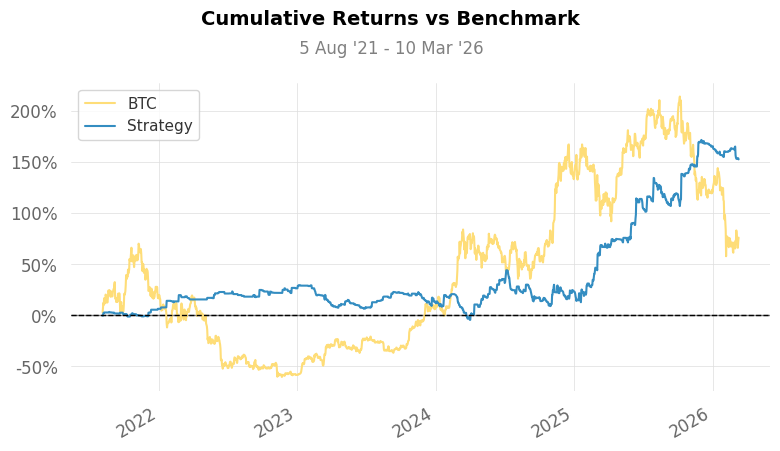

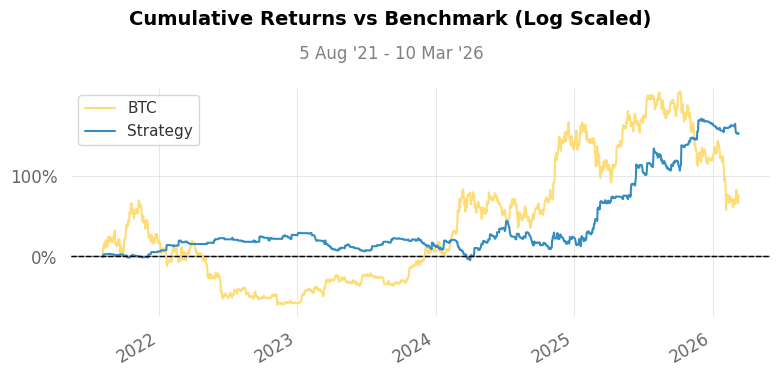

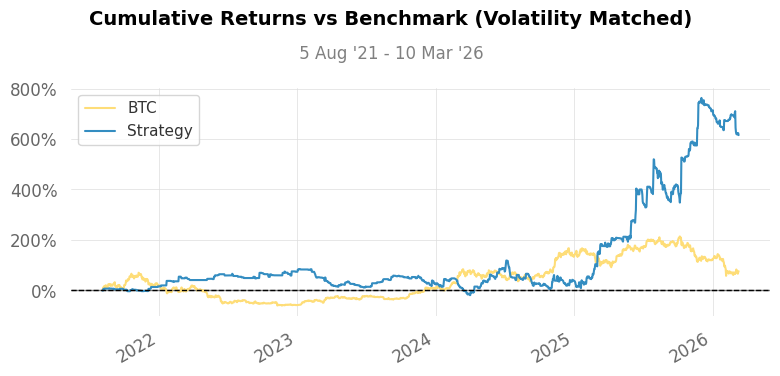

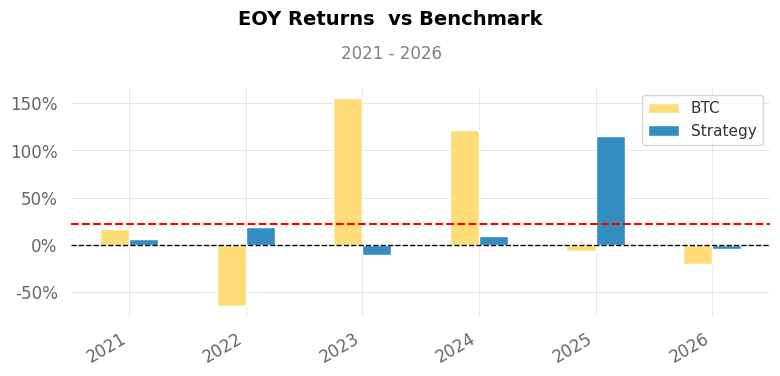

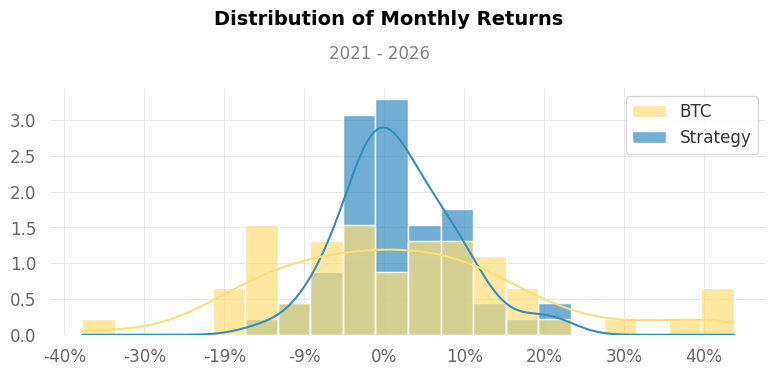

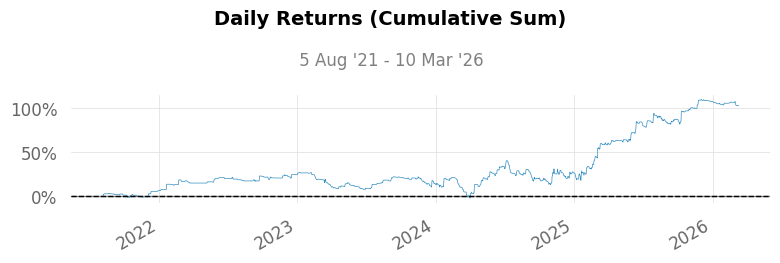

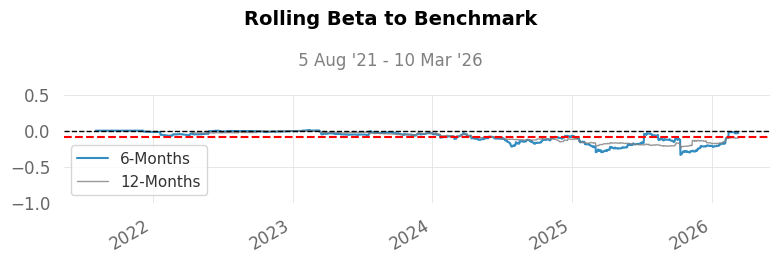

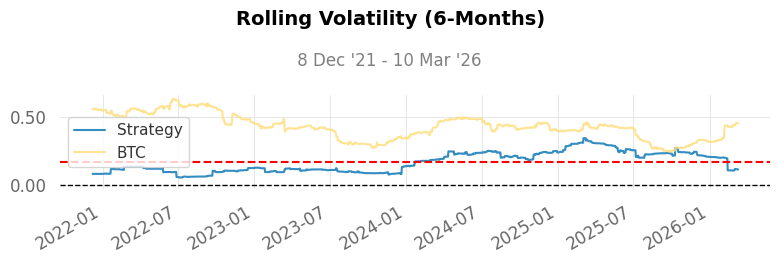

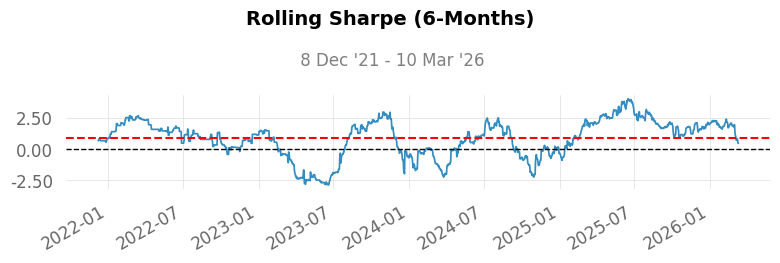

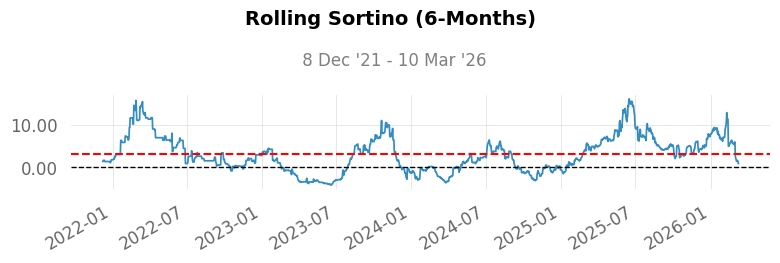

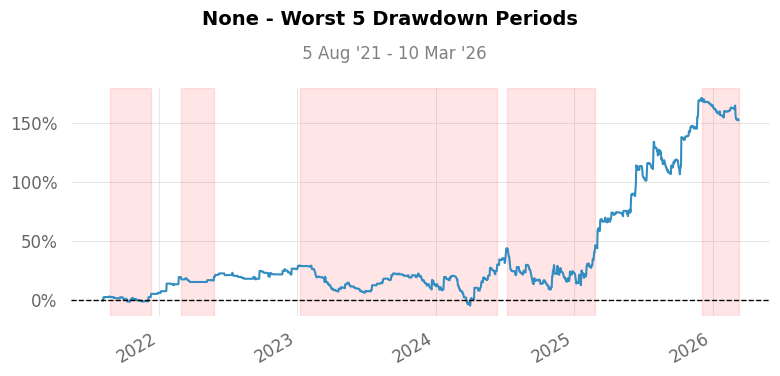

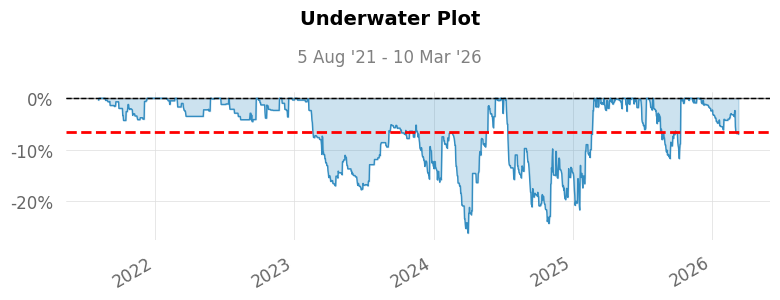

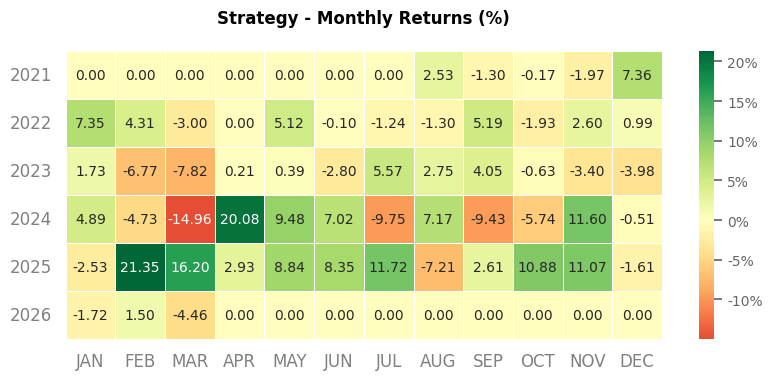

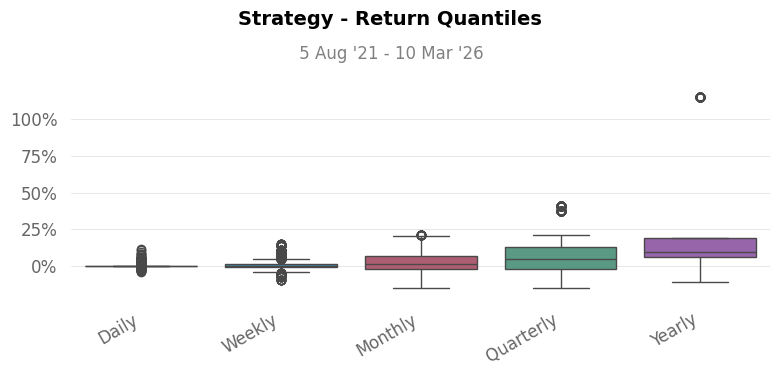

In [7]:
qs.reports.full(
    returns,
    benchmark=benchmark,
    benchmark_title='BTC',
    rf=0.0,
    title=REPORT_TITLE
)

---
## Daily Returns Heatmap

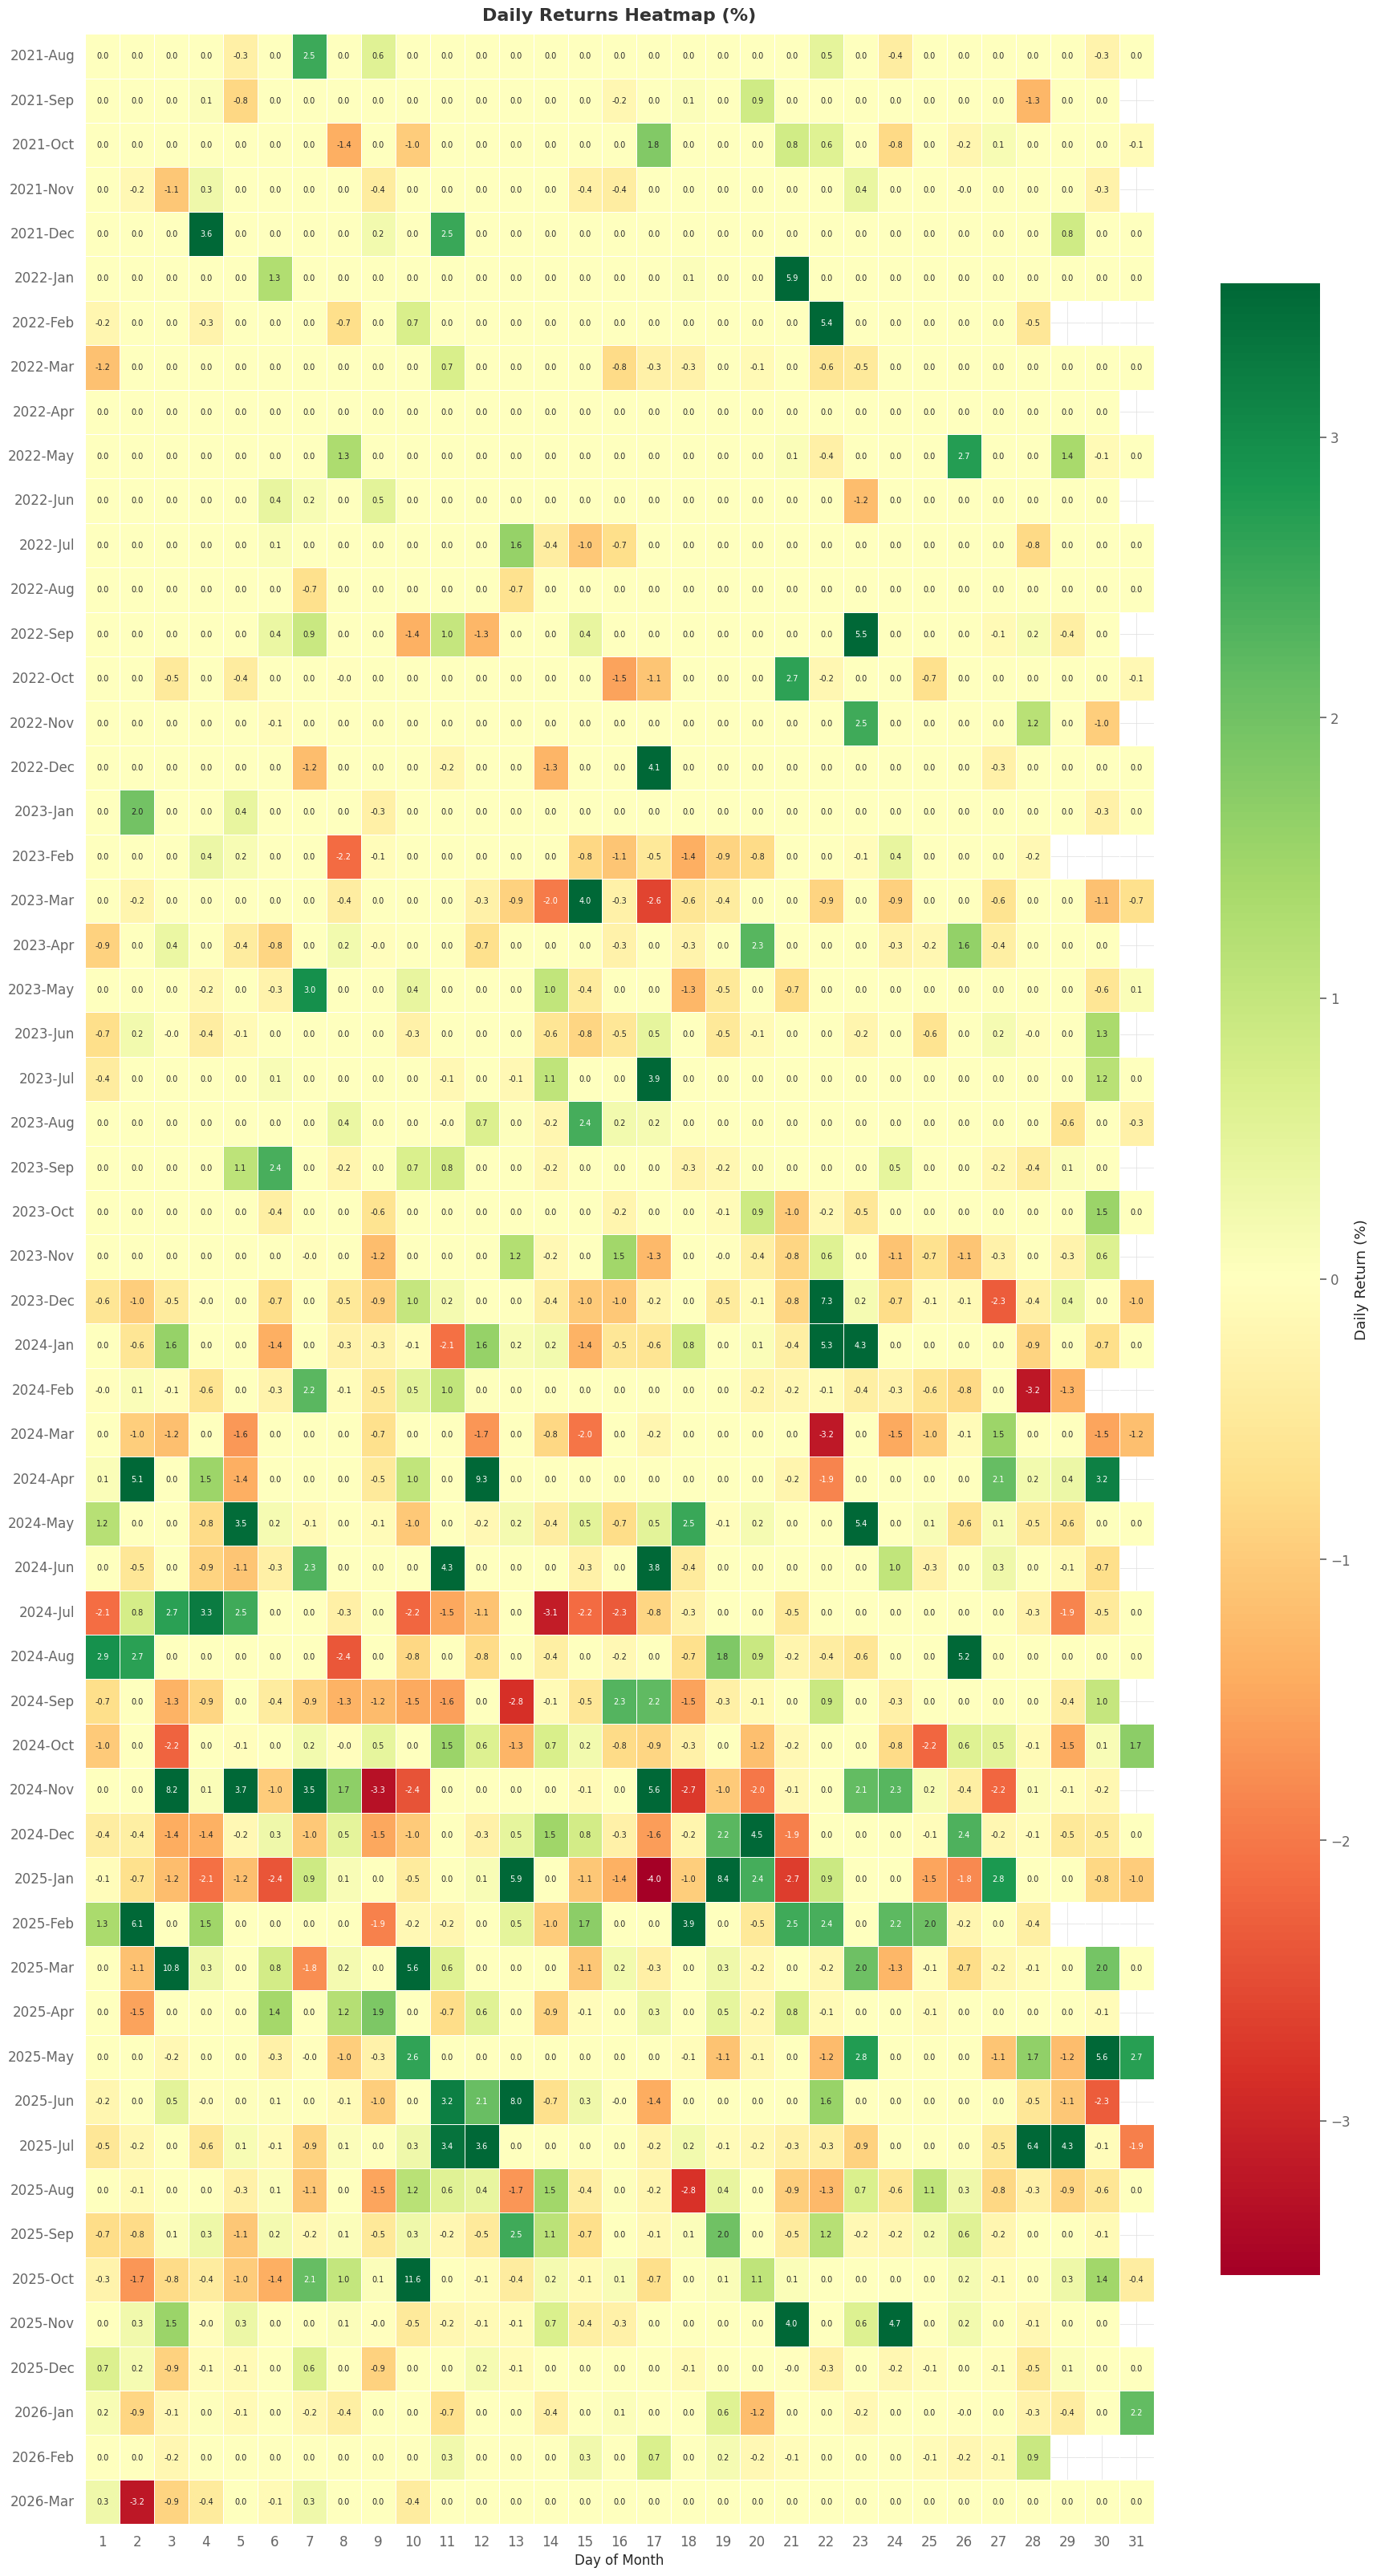

In [8]:
import calendar

def plot_daily_returns_heatmap(returns_series):
    daily = returns_series.copy() * 100
    df = pd.DataFrame({'ret': daily})
    df['year_month'] = df.index.strftime('%Y-%b')
    df['day'] = df.index.day

    pivot = df.pivot_table(index='year_month', columns='day', values='ret', aggfunc='sum')
    pivot = pivot.reindex(columns=range(1, 32))
    month_order = df.groupby('year_month').apply(lambda x: x.index.min()).sort_values()
    pivot = pivot.reindex(month_order.index)

    impossible = pd.DataFrame(False, index=pivot.index, columns=pivot.columns)
    for ym_label in pivot.index:
        first_date = month_order[ym_label]
        year, month = first_date.year, first_date.month
        days_in_month = calendar.monthrange(year, month)[1]
        for day_col in pivot.columns:
            if day_col > days_in_month:
                impossible.loc[ym_label, day_col] = True
    pivot = pivot.where(impossible | pivot.notna(), 0.0)

    n_months = len(pivot)
    fig_height = max(4, n_months * 0.55 + 1.5)
    fig, ax = plt.subplots(figsize=(18, fig_height))

    flat = pivot.values.flatten()
    flat = flat[~np.isnan(flat)]
    vmax = np.percentile(np.abs(flat), 98) if len(flat) > 0 else 1

    sns.heatmap(
        pivot, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
        linewidths=0.5, linecolor='white', vmin=-vmax, vmax=vmax,
        mask=impossible, ax=ax,
        cbar_kws={'label': 'Daily Return (%)', 'shrink': 0.8},
        annot_kws={'size': 7},
    )

    ax.set_title('Daily Returns Heatmap (%)', fontsize=16, fontweight='bold', pad=12)
    ax.set_ylabel('')
    ax.set_xlabel('Day of Month', fontsize=12)
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.show()

plot_daily_returns_heatmap(returns)

---
## Key Performance Metrics

In [9]:
metrics = qs.reports.metrics(returns, benchmark=benchmark, rf=0.0, display=False)

pct_keywords = [
    'Risk-Free Rate', 'Time in Market', 'Cumulative Return', 'CAGR',
    'Prob. Sharpe Ratio', 'Max Drawdown', 'Volatility (ann.)', 'R^2',
    'Risk-Adjusted Return', 'Avg. Return', 'Avg. Win', 'Avg. Loss',
    'Expected Daily', 'Expected Monthly', 'Expected Yearly',
    'Kelly Criterion', 'Risk of Ruin', 'Daily Value-at-Risk',
    'Expected Shortfall', 'MTD', '3M', '6M', 'YTD', '1Y',
    '3Y (ann.)', '5Y (ann.)', '10Y (ann.)', 'All-time (ann.)',
    'Best Day', 'Worst Day', 'Best Month', 'Worst Month',
    'Best Year', 'Worst Year', 'Avg. Drawdown', 'Avg. Up Month',
    'Avg. Down Month', 'Win Days', 'Win Month', 'Win Quarter',
    'Win Year', 'Alpha', 'Correlation', 'Treynor Ratio'
]

def is_pct_metric(idx):
    return any(kw in idx for kw in pct_keywords)

metrics_fmt = metrics.copy()
for idx in metrics_fmt.index:
    if is_pct_metric(idx):
        for col in metrics_fmt.columns:
            val = metrics_fmt.loc[idx, col]
            if pd.notna(val) and isinstance(val, (int, float)):
                metrics_fmt.loc[idx, col] = f'{val*100:.2f}%'

display(metrics_fmt.style.set_caption(METRICS_CAPTION).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('padding', '10px')]},
    {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('padding', '6px')]},
    {'selector': 'td', 'props': [('padding', '4px 8px')]},
]))

,Benchmark,Strategy
Start Period,2021-08-05,2021-08-05
End Period,2026-03-10,2026-03-10
Risk-Free Rate,0.00%,0.00%
Time in Market,100.00%,46.00%
Cumulative Return,76.00%,152.00%
CAGR﹪,9.00%,15.00%
Sharpe,0.410000,0.870000
Prob. Sharpe Ratio,86.00%,99.00%
Sortino,0.600000,1.920000
Sortino/√2,0.430000,1.360000


---
## Breakdown by Trading Pair

In [10]:
def _pair_breakdown(df_trades):
    """Build per-pair stats matching tradeexecutor/analysis/multipair.py columns."""
    stats = df_trades.groupby('pair').agg(
        positions=('profit_abs', 'count'),
        total_pnl=('profit_abs', 'sum'),
        total_return_pct=('profit_ratio', lambda x: x.sum() * 100),
        best=('profit_ratio', lambda x: x.max() * 100),
        worst=('profit_ratio', lambda x: x.min() * 100),
        avg=('profit_ratio', lambda x: x.mean() * 100),
        median=('profit_ratio', lambda x: x.median() * 100),
        volume=('stake_amount', 'sum'),
        wins=('profit_abs', lambda x: (x > 0).sum()),
        losses=('profit_abs', lambda x: (x <= 0).sum()),
        take_profits=('exit_reason', lambda x: (x == 'roi').sum()),
        stop_losses=('exit_reason', lambda x: x.isin(['stop_loss', 'stoploss_on_exchange']).sum()),
        trailing_stops=('exit_reason', lambda x: (x == 'trailing_stop_loss').sum()),
        volatility=('profit_ratio', lambda x: x.std() * 100),
    ).round(2).sort_values('total_pnl', ascending=False)

    stats.columns = [
        'Positions', 'Total PnL USD', 'Total Return %',
        'Best %', 'Worst %', 'Avg %', 'Median %',
        'Volume', 'Wins', 'Losses',
        'Take Profits', 'Stop Losses', 'Trailing Stops', 'Volatility %',
    ]
    return stats

def _color_pnl(val):
    if isinstance(val, (int, float)):
        return f'color: {"#27ae60" if val > 0 else "#c0392b" if val < 0 else "#2c3e50"}'
    return ''

_fmt = {
    'Total PnL USD': '{:+.2f}', 'Total Return %': '{:+.2f}%',
    'Best %': '{:+.2f}%', 'Worst %': '{:+.2f}%',
    'Avg %': '{:+.2f}%', 'Median %': '{:+.2f}%',
    'Volume': '{:,.0f}', 'Volatility %': '{:.2f}%',
    'Positions': '{:.0f}', 'Wins': '{:.0f}', 'Losses': '{:.0f}',
    'Take Profits': '{:.0f}', 'Stop Losses': '{:.0f}', 'Trailing Stops': '{:.0f}',
}
_pnl_cols = ['Total PnL USD', 'Total Return %', 'Best %', 'Worst %', 'Avg %', 'Median %']
_tbl_styles = [
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('padding', '10px')]},
    {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('padding', '6px')]},
    {'selector': 'td', 'props': [('padding', '4px 8px')]},
]

pair_stats = _pair_breakdown(trades)
display(pair_stats.style
    .applymap(_color_pnl, subset=_pnl_cols)
    .format(_fmt)
    .set_caption('Per-Pair Performance Summary (sorted by Total PnL)')
    .set_table_styles(_tbl_styles)
)

,Positions,Total PnL USD,Total Return %,Best %,Worst %,Avg %,Median %,Volume,Wins,Losses,Take Profits,Stop Losses,Trailing Stops,Volatility %
pair,,,,,,,,,,,,,,
HYPE/USDC:USDC,18,+27464.06,+105.76%,+47.63%,-8.13%,+5.88%,-0.11%,"520,722",9,9,0,3,9,13.90%
XRP/USDC:USDC,87,+22881.37,+86.75%,+27.86%,-7.13%,+1.00%,-0.29%,"1,957,922",40,47,0,27,35,5.65%
SOL/USDC:USDC,84,+18350.28,+76.76%,+25.59%,-7.13%,+0.91%,-1.91%,"2,269,740",38,46,0,7,49,6.79%
FARTCOIN/USDC:USDC,22,+17085.04,+111.66%,+74.11%,-13.01%,+5.08%,+3.78%,"376,737",13,9,0,3,8,18.00%
LINK/USDC:USDC,54,+15567.36,+64.07%,+24.25%,-9.40%,+1.19%,-2.38%,"1,469,982",24,30,0,7,30,7.69%
RENDER/USDC:USDC,15,+14839.52,+84.12%,+35.47%,-9.73%,+5.61%,+5.91%,"166,048",9,6,0,3,5,11.35%
NEAR/USDC:USDC,61,+13746.00,+101.73%,+30.60%,-6.98%,+1.67%,-1.10%,"1,004,327",29,32,0,26,9,7.82%
PEPE/USDC:USDC,37,+11979.99,+65.87%,+25.23%,-7.95%,+1.78%,-1.66%,"675,241",18,19,0,9,11,9.66%
ARB/USDC:USDC,46,+9754.10,+62.21%,+17.35%,-11.09%,+1.35%,+0.02%,"735,748",23,23,0,12,16,7.14%


In [11]:
def _display_side_breakdown(df_side, side_label):
    """Display per-pair stats for one side (long or short)."""
    if len(df_side) == 0:
        print(f"No {side_label} trades found.")
        return
    stats = _pair_breakdown(df_side)
    display(stats.style
        .applymap(_color_pnl, subset=_pnl_cols)
        .format(_fmt)
        .set_caption(f'{side_label} Positions by Pair (sorted by Total PnL)')
        .set_table_styles(_tbl_styles)
    )

_display_side_breakdown(trades[trades['is_short'] == False], 'Long')
_display_side_breakdown(trades[trades['is_short'] == True], 'Short')

,Positions,Total PnL USD,Total Return %,Best %,Worst %,Avg %,Median %,Volume,Wins,Losses,Take Profits,Stop Losses,Trailing Stops,Volatility %
pair,,,,,,,,,,,,,,
SOL/USDC:USDC,28,+14044.76,+43.92%,+25.59%,-7.13%,+1.57%,-1.50%,"772,806",12,16,0,0,15,7.95%
XRP/USDC:USDC,25,+12842.65,+45.79%,+27.86%,-6.68%,+1.83%,-1.02%,"554,822",10,15,0,0,17,8.28%
FARTCOIN/USDC:USDC,12,+12762.14,+86.00%,+74.11%,-13.00%,+7.17%,-0.38%,"219,052",6,6,0,1,7,23.73%
DOLO/USDC:USDC,11,+9584.84,+178.18%,+169.36%,-13.00%,+16.20%,-6.03%,"103,694",4,7,0,2,7,53.54%
RENDER/USDC:USDC,5,+7254.67,+31.06%,+35.47%,-5.46%,+6.21%,-1.83%,"48,630",2,3,0,1,2,16.90%
HYPE/USDC:USDC,7,+6935.25,+14.87%,+19.04%,-4.31%,+2.12%,-1.56%,"240,022",3,4,0,0,6,8.33%
SUI/USDC:USDC,15,+5105.18,+14.93%,+15.29%,-6.14%,+1.00%,-0.27%,"341,000",7,8,0,1,8,6.19%
LDO/USDC:USDC,5,+5035.54,+27.21%,+14.45%,-2.33%,+5.44%,+4.33%,"74,744",3,2,0,0,1,7.70%
PEPE/USDC:USDC,13,+4584.16,+18.51%,+25.23%,-7.95%,+1.42%,-1.82%,"274,664",5,8,0,0,9,10.50%


,Positions,Total PnL USD,Total Return %,Best %,Worst %,Avg %,Median %,Volume,Wins,Losses,Take Profits,Stop Losses,Trailing Stops,Volatility %
pair,,,,,,,,,,,,,,
LINK/USDC:USDC,42,+20684.69,+78.01%,+24.25%,-8.49%,+1.86%,-1.39%,"1,177,842",20,22,0,6,23,8.07%
HYPE/USDC:USDC,11,+20528.81,+90.89%,+47.63%,-8.13%,+8.26%,+1.49%,"280,699",6,5,0,3,3,16.45%
NEAR/USDC:USDC,46,+16009.50,+105.98%,+30.60%,-5.41%,+2.30%,-1.06%,"719,340",22,24,0,23,6,8.54%
ARB/USDC:USDC,37,+13627.57,+82.86%,+17.35%,-7.77%,+2.24%,+0.79%,"574,258",21,16,0,12,8,7.05%
XRP/USDC:USDC,62,+10038.72,+40.97%,+10.35%,-7.13%,+0.66%,-0.08%,"1,403,100",30,32,0,27,18,4.20%
UNI/USDC:USDC,72,+9290.24,+78.46%,+27.23%,-6.56%,+1.09%,-1.80%,"1,221,473",33,39,0,26,27,6.35%
DOGE/USDC:USDC,25,+9247.78,+46.31%,+15.72%,-7.36%,+1.85%,-0.12%,"474,406",12,13,0,10,6,6.98%
RENDER/USDC:USDC,10,+7584.85,+53.06%,+16.11%,-9.73%,+5.31%,+7.69%,"117,418",7,3,0,2,3,8.56%
AVAX/USDC:USDC,24,+7575.05,+42.44%,+27.76%,-9.01%,+1.77%,-3.18%,"286,297",8,16,0,3,13,9.22%


---
## Export QuantStats HTML Report

In [12]:
if HTML_OUTPUT_FILENAME:
    _nb_dir = Path('notebooks/analysis')
    _html_path = _nb_dir / HTML_OUTPUT_FILENAME

    qs.reports.html(
        returns,
        benchmark=benchmark,
        benchmark_title='BTC',
        rf=0.0,
        output=str(_html_path),
        title=REPORT_TITLE,
    )

    # --- Inject per-pair breakdown + strip "(Compounded)" from title ---

    def _build_pair_html_table(df_trades, title):
        """Build an HTML table matching tradeexecutor/analysis/multipair.py columns."""
        stats = _pair_breakdown(df_trades)

        cols = stats.columns.tolist()
        pnl_like = {'Total PnL USD', 'Total Return %', 'Best %', 'Worst %', 'Avg %', 'Median %'}
        pct_fmt = {'Total Return %', 'Best %', 'Worst %', 'Avg %', 'Median %', 'Volatility %'}
        int_cols = {'Positions', 'Wins', 'Losses', 'Take Profits', 'Stop Losses', 'Trailing Stops'}

        header = ''.join(
            f'<th style="text-align:{"left" if c == cols[0] else "right"}">{c}</th>' for c in ['Pair'] + cols
        )

        rows_html = ''
        for pair, r in stats.iterrows():
            cells = f'<td style="text-align:left">{pair}</td>'
            for c in cols:
                v = r[c]
                if c in pnl_like:
                    color = '#27ae60' if v > 0 else '#c0392b' if v < 0 else '#2c3e50'
                    style = f'color:{color}'
                    if c == 'Total PnL USD':
                        style += ';font-weight:bold'
                    txt = f'{v:+.2f}%' if c in pct_fmt else f'{v:+.2f}'
                elif c in pct_fmt:
                    style = ''
                    txt = f'{v:.2f}%'
                elif c in int_cols:
                    style = ''
                    txt = f'{int(v)}'
                elif c == 'Volume':
                    style = ''
                    txt = f'{v:,.0f}'
                else:
                    style = ''
                    txt = f'{v}'
                cells += f'<td style="{style}">{txt}</td>'
            rows_html += f'<tr>{cells}</tr>\n'

        return f'''
        <h3>{title}</h3>
        <table>
            <thead><tr>{header}</tr></thead>
            <tbody>{rows_html}</tbody>
        </table>
        '''

    _pair_section = '<div style="clear:both"></div><hr>\n'
    _pair_section += _build_pair_html_table(trades, 'Breakdown by Trading Pair')
    _pair_section += _build_pair_html_table(trades[trades['is_short'] == False], 'Long Positions by Pair')
    _pair_section += _build_pair_html_table(trades[trades['is_short'] == True], 'Short Positions by Pair')

    with open(_html_path, 'r') as f:
        _report_html = f.read()

    _report_html = _report_html.replace(' (Compounded)', '')
    _report_html = _report_html.replace(
        '</div>\n    <style>*{white-space',
        _pair_section + '\n    </div>\n    <style>*{white-space'
    )

    with open(_html_path, 'w') as f:
        f.write(_report_html)

    from IPython.display import display, HTML
    display(HTML(
        f'<div style="padding:12px 16px;background:#d4edda;color:#155724;border-radius:6px;font-size:14px">'
        f'\u2705 QuantStats HTML report saved to <code>{_html_path}</code> (with per-pair breakdown)</div>'
    ))
else:
    print('HTML export skipped (HTML_OUTPUT_FILENAME is None)')

---
*Report generated from backtest data. Force-exited trades excluded. Benchmark: BTC buy-and-hold.*  
*Backtests are not indicative of future performance. Past results may not reflect live trading conditions including slippage, liquidity, and exchange-specific behaviour.*